In [1]:
%load_ext autoreload
%autoreload 2
%reset -f

# Imports

In [2]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import pandas as pd
import geopandas as gpd
import contextily as ctx
import pandas as pd
import os

import sys
import os

%matplotlib widget
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from h3 import *
from shapely.geometry import Point
from shapely.geometry import LineString, Point
import numpy as np

os.chdir('/home/sandbox/personal-repos/DA-3507/dump')
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../lib')))
from custom_pandas import *

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/geopandas/_compat.py:154: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  set_use_pygeos()


EU1_Conn created successfully
EU2_Conn created successfully
DataHub_Conn created successfully
US_Conn created successfully


# Configuration

In [3]:
street_length = 10
sampling_period = 5
line_length = 10

## Query the surveys

In [4]:
a = get_reports('Cadent',years = [2026]).execute([EU2_Conn])
report_bc = a.iloc[[800]].copy()

## Query the geometries

In [5]:
report_bc.db.set_query(query_SurveyH3Aggregation_byReport(report_table = '#TempReport'))
agg_segments =report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')
report_bc.db.set_query(query_Segments_byReport(report_table = '#TempReport'))
segments = report_bc.db.execute([EU2_Conn], source_col = 'ReportId', temp_table_name = '#TempReport')

## Isolate a single survey

In [6]:
l = 0
surveys = segments['SurveyId'].unique()
survey = segments[segments['SurveyId'] == surveys[l]]
#survey = segments
survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)

/tmp/ipykernel_22776/3614139279.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  survey['Breadcrumb_wkt'] = survey['Breadcrumb'].apply(wkt.loads)


## Prepare the countour geometry

In [7]:
contour = agg_segments[agg_segments['SurveyId'] == surveys[l]]
contour['Breadcrumb_wkt'] = contour['Breadcrumb'].apply(wkt.loads)
contour_gdf = gpd.GeoDataFrame(contour, geometry = 'Breadcrumb_wkt', crs = 'EPSG:4326')
contour_gdf = contour_gdf.to_crs(utm_crs)
contour_gdf['offset'] = contour_gdf.geometry.buffer(street_length/2, cap_style=2)


/tmp/ipykernel_22776/1813949946.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contour['Breadcrumb_wkt'] = contour['Breadcrumb'].apply(wkt.loads)


## Create a evenly spaced grid over the line

In [8]:
def sample_linearly(line, distance):
    if not isinstance(line, LineString):
        return []
    length = line.length
    # Compute evenly spaced distances along the line, but exclude endpoints
    num_points = int(np.floor(length / distance)) + 1
    if np.isclose(num_points * distance, length):
        distances = np.linspace(0, length, num=num_points + 1)
    else:
        distances = np.arange(0, length, distance)
        if length not in distances:
            distances = np.append(distances, length)
    # Remove starting (0) and ending (length) point
    distances = [d for d in distances if not np.isclose(d, 0) and not np.isclose(d, length)]
    return [line.interpolate(d) for d in distances]

survey_gdf['EvenlySpaced'] = survey_gdf.geometry.apply(lambda line: sample_linearly(line, sampling_period))
#survey_gdf['EvenlySpaced'] = survey_gdf.geometry.segmentize(sampling_period)

# Create the geometry from list of points, plot the result
survey_gdf['EvenlySpacedLine'] = survey_gdf['EvenlySpaced'].apply(lambda pts: LineString(pts) if len(pts) >= 2 else None)
#survey_gdf['EvenlySpacedLine'] = survey_gdf['EvenlySpaced']

survey_gdf['EvenlySpacedLine']

0      LINESTRING (547894.081548391 5938569.868061133...
1      LINESTRING (547983.216873724 5938986.730908428...
2      LINESTRING (548132.3899379034 5938910.48083632...
3      LINESTRING (548086.0145047398 5938347.96559347...
4      LINESTRING (548248.9320087379 5938809.04093050...
                             ...                        
140    LINESTRING (547612.479712142 5938560.385343491...
141    LINESTRING (548008.4962310091 5938602.46927773...
142    LINESTRING (547961.4638748238 5938980.90901165...
143    LINESTRING (548168.055685762 5938846.166055264...
144    LINESTRING (547533.3596262056 5938664.33360700...
Name: EvenlySpacedLine, Length: 145, dtype: object

# Create a line perpendicular line at each vertex

In [9]:
import numpy as np
from shapely.geometry import LineString, Point

def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def perpendicular_vector(dx, dy):
    """ Returns a perpendicular vector (to the left of direction of travel). """
    return np.array([-dy, dx])

def perp_lines_at_vertices(line, length=10):
    """Generate perpendicular lines at each vertex of a LineString."""
    coords = list(line.coords)
    perps = []
    n = len(coords)

    for i, (x, y) in enumerate(coords):
        # For endpoints, use segment direction from second/previous point
        if n < 2:
            continue  # Not enough points
        elif i == 0:
            x2, y2 = coords[i + 1]
            dx, dy = x2 - x, y2 - y
        elif i == n - 1:
            x1, y1 = coords[i - 1]
            dx, dy = x - x1, y - y1
        else:
            # Average both directions for a smoother result
            x1, y1 = coords[i - 1]
            x2, y2 = coords[i + 1]
            dx1, dy1 = x - x1, y - y1
            dx2, dy2 = x2 - x, y2 - y
            dx, dy = unit_vector(np.array([dx1, dy1])) + unit_vector(np.array([dx2, dy2]))
            if np.linalg.norm([dx, dy]) == 0:  # colinear back-to-back turn, fallback
                dx, dy = -dy1, dx1

        direction = unit_vector(np.array([dx, dy]))
        perp = perpendicular_vector(*direction)
        midpoint = np.array([x, y])
        half = (length / 2.0) * perp
        line_pts = [midpoint - half, midpoint + half]
        perps.append(LineString(line_pts))

    return perps

perp_lines = []
for geom in survey_gdf.EvenlySpacedLine:
    if isinstance(geom, LineString):
        perp_lines.extend(perp_lines_at_vertices(geom, length=line_length))

perp_gdf = gpd.GeoDataFrame(geometry=perp_lines, crs=survey_gdf.crs if hasattr(survey_gdf, 'crs') else None)
perp_gdf = perp_gdf.reset_index(drop=True)
perp_gdf.index = pd.Index(range(len(perp_gdf)), name='perp_id')

# Create the intersection for getting the number of passes

In [10]:
points = gpd.overlay(perp_gdf, survey_gdf, how='intersection', keep_geom_type=False)[['geometry','Order']]
# Expand any MultiPoint into two points (or more, as many as present), else leave as is
expanded_points = []
for geom in points['geometry']:
    if geom.geom_type == 'MultiPoint':
        expanded_points.extend(list(geom.geoms)[:2])  # take first 2 points
    else:
        expanded_points.append(geom)
expanded_points = gpd.GeoDataFrame(geometry=expanded_points, crs=points.crs if hasattr(points, 'crs') else None)
buffered_points = expanded_points.buffer(0.001)

In [11]:
buffered_points_gdf = gpd.GeoDataFrame(geometry=buffered_points, crs=expanded_points.crs if hasattr(expanded_points, 'crs') else None)
buffered_points_gdf

,geometry
0,"POLYGON ((547894.083 5938569.868, 547894.083 5..."
1,"POLYGON ((547889.247 5938571.140, 547889.247 5..."
2,"POLYGON ((547888.166 5938576.019, 547888.166 5..."
3,"POLYGON ((547887.088 5938580.902, 547887.088 5..."
4,"POLYGON ((547887.371 5938585.813, 547887.371 5..."
...,...
32423,"POLYGON ((548037.145 5938354.506, 548037.145 5..."
32424,"POLYGON ((548032.404 5938356.095, 548032.404 5..."
32425,"POLYGON ((548027.663 5938357.684, 548027.663 5..."
32426,"POLYGON ((548022.922 5938359.273, 548022.922 5..."


In [12]:
joined = gpd.sjoin(buffered_points_gdf, perp_gdf, how='left', predicate='intersects')

In [13]:
# Join the count of points (number of passes) with perp_gdf by perp_id
count_by_perp = joined['index_right'].value_counts().rename_axis('perp_id').reset_index(name='count')
perp_gdf_with_count = perp_gdf.reset_index().merge(count_by_perp, on='perp_id', how='left').set_index('perp_id')
perp_gdf_with_count

,geometry,count
perp_id,,
0,"LINESTRING (547895.354 5938574.704, 547892.809...",4
1,"LINESTRING (547892.850 5938574.606, 547885.642...",5
2,"LINESTRING (547893.047 5938577.099, 547883.283...",8
3,"LINESTRING (547892.071 5938581.301, 547882.103...",7
4,"LINESTRING (547892.337 5938585.235, 547882.404...",7
...,...,...
5374,"LINESTRING (547683.375 5938574.082, 547688.283...",8
5375,"LINESTRING (547687.731 5938571.627, 547692.639...",8
5376,"LINESTRING (547692.087 5938569.173, 547696.996...",8


# Check the histograms

In [14]:
perp_gdf_with_count['count'].value_counts()

count
4     1391
8     1168
6      664
5      627
7      509
9      432
3      209
10     158
2      120
1       60
12      39
11       2
Name: count, dtype: int64

<Axes: >

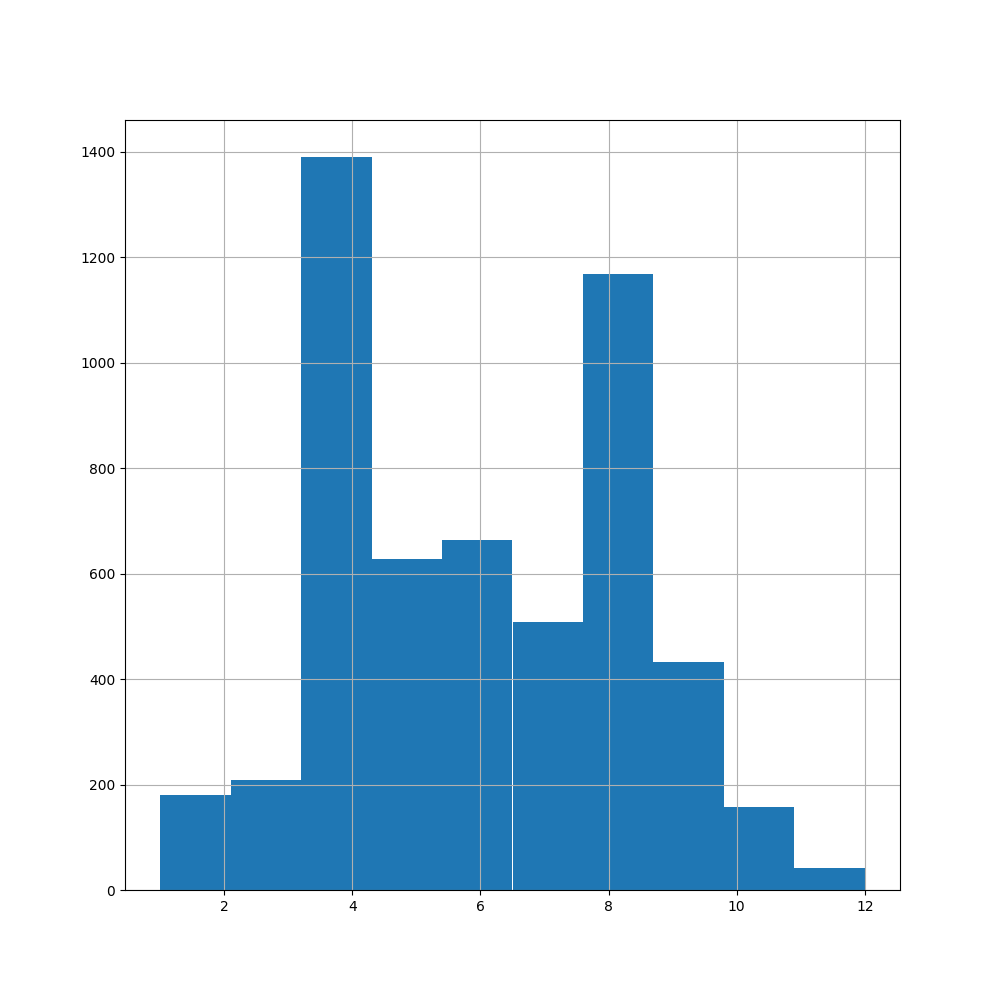

In [15]:

fig,axr = plt.subplots(figsize=(10,10))
perp_gdf_with_count['count'].hist(ax=axr)


# Plotting

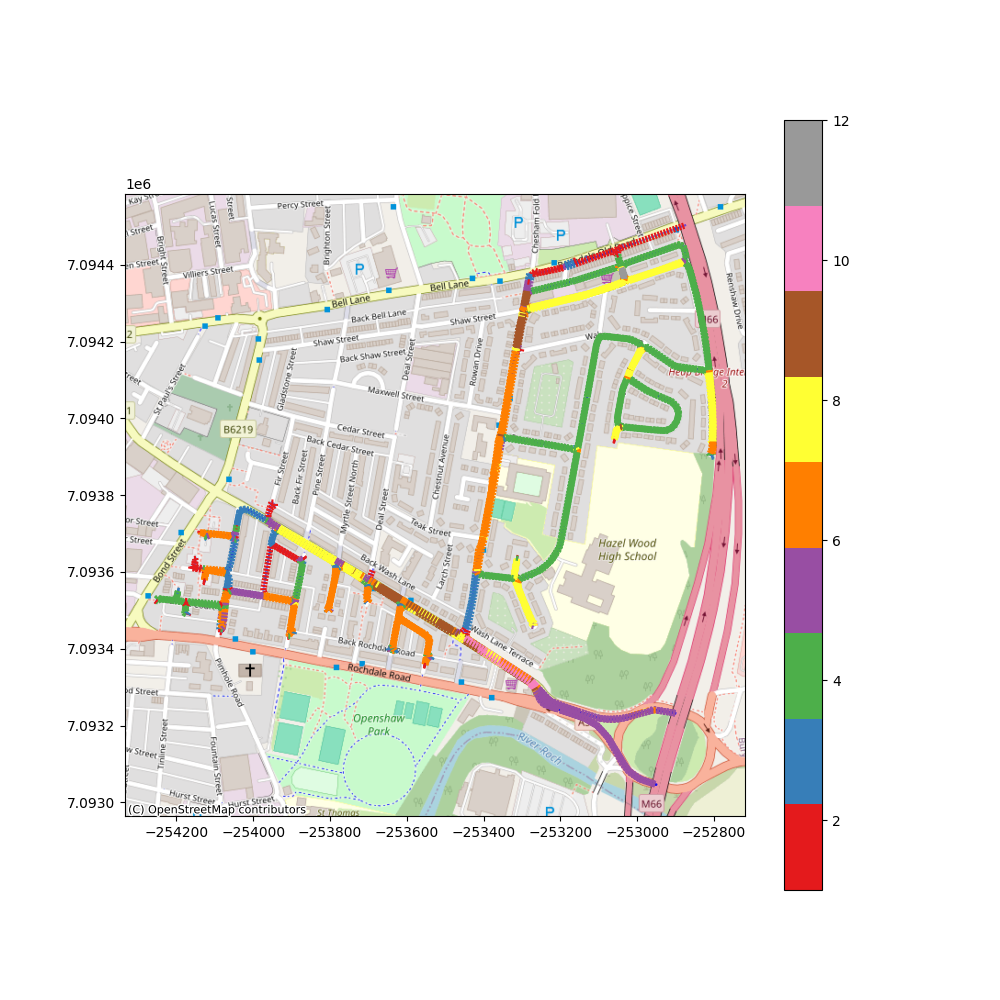

In [16]:
import contextily as ctx

fig, axr = plt.subplots(figsize=(10,10))

survey_gdf.to_crs(epsg=3857).plot(ax=axr, color='blue', alpha=0.5)
perp_gdf_with_count.to_crs(epsg=3857).plot(ax=axr, legend=True, column='count', cmap='Set1')
contour_gdf.offset.to_crs(epsg=3857).plot(ax=axr, color='red', alpha=0.0)

ctx.add_basemap(axr, source=ctx.providers.OpenStreetMap.Mapnik, crs='EPSG:3857')

In [17]:
perp_gdf_with_count['centroid'] = perp_gdf_with_count['geometry'].centroid

In [18]:
perp_2 = perp_gdf_with_count[perp_gdf_with_count['count'] == 2]
max_dist = 20
line_list = []
line_pts = []
done_line = True
done_list = True
i = 0
# ignoring all warnings as requested
out = []
from scipy.spatial import cKDTree
import numpy as np

# Get centroid coordinates as array for KDTree
centroids = np.array(list(perp_2['centroid'].apply(lambda x: (x.x, x.y))))
tree = cKDTree(centroids)
used = np.zeros(len(perp_2), dtype=bool)

for i in range(len(perp_2)):
    if used[i]:
        continue
    # Query KDTree for neighbors within max_dist (including self)
    idxs = tree.query_ball_point(centroids[i], r=max_dist)
    idxs = [idx for idx in idxs if not used[idx]]
    if len(idxs) >= 2:
        # Build line from the found cluster
        line = LineString([perp_2.iloc[idx]['centroid'].coords[0] for idx in idxs])
        line_list.append(line)
        # Mark these as used
        used[idxs] = True
    else:
        # Not enough close points (including itself)
        out = [perp_2.iloc[idx] for idx in idxs]
        print(out)
        used[idxs] = True
   


[geometry    LINESTRING (547947.6617378148 5938909.33148331...
count                                                       2
centroid          POINT (547946.7500469523 5938914.247662706)
Name: 2226, dtype: object]
[geometry    LINESTRING (547503.2398109242 5938541.06649162...
count                                                       2
centroid           POINT (547498.319222415 5938541.954077519)
Name: 4154, dtype: object]
[geometry    LINESTRING (547387.1739416248 5938519.01999263...
count                                                       2
centroid          POINT (547390.3601304389 5938522.873328957)
Name: 4692, dtype: object]


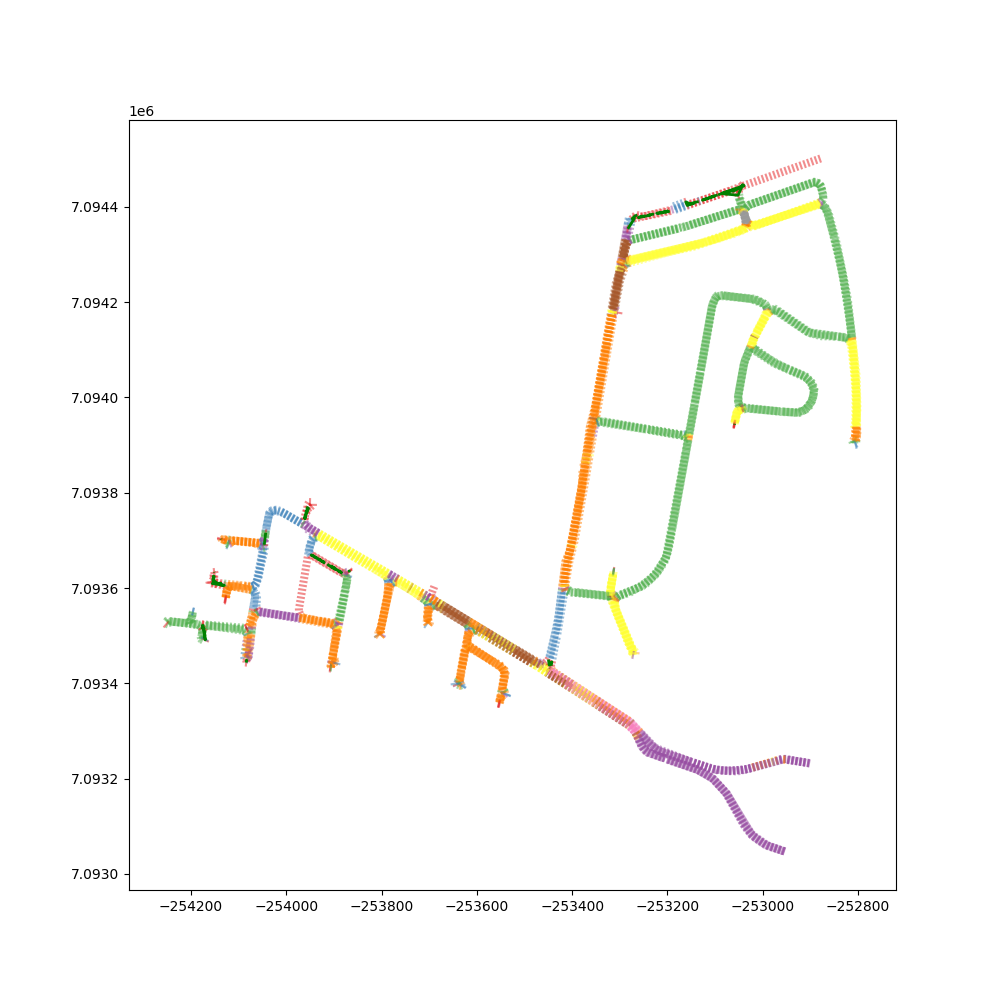

In [19]:
import geopandas as gpd
from shapely.geometry import LineString
fig, ax5 = plt.subplots(figsize=(10,10))

# Convert the list of LineString objects to a GeoDataFrame
lines_gdf = gpd.GeoDataFrame(geometry=line_list, crs=perp_gdf_with_count.crs if hasattr(perp_gdf_with_count, 'crs') else "EPSG:3857")
lines_gdf = lines_gdf.to_crs(epsg=3857)
perp_gdf_with_count.to_crs(epsg=3857).plot(ax=ax5, column='count', cmap='Set1', alpha=0.5)


# Plot the lines
lines_gdf.plot(ax=ax5, color='green', linewidth=2)

plt.show()
